# Лабораторная работа №1. Регрессия и метод главных компонент
Выполнил: Сорочинский Михаил Владимирович, АВТ-314

Проверил: Антонянц Егор Николаевич
## 1. Введение

- **Цель работы:** изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.
- **Задачи:**
  1. Загрузить датасет California Housing Prices с Kaggle.
  2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.
  3. Провести предобработку данных: обработать пропущенные значения, закодировать категориальные переменные.
  4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).
  5. Построить регрессионные модели (линейная, лассо и гребневая). Разделить на тренировочную и тестовую выборки (80/20). Использовать кросс-валидацию. Оценить качество метриками RMSE, R² и MAPE.
  6. Устранить мультиколлинеарность и снизить размерность признаков с помощью PCA. Перед PCA провести стандартизацию.
  7. Повторить шаг 5 на главных компонентах и сравнить метрики с моделями на исходных признаках.
- **Целевая переменная:** `Медианная цена дома` ($) — непрерывная, поэтому логистическая регрессия не строится.

> **Примечание по источнику.** Датасет `shraddha4ever20/california-housing-dataset` содержит только признаки sklearn-версии **без целевой цены**. Для регрессии использован полный классический набор [California Housing Prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices) (`camnugent/california-housing-prices`): те же районы Калифорнии (перепись 1990), плюс `median_house_value` и категориальный `ocean_proximity`.


In [1]:
import json
import warnings
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    mape = float(mean_absolute_percentage_error(y_true, y_pred) * 100)
    return rmse, r2, mape

def label_component(series):
    s = series.abs().sort_values(ascending=False)
    top = s.head(3)
    names = list(top.index)
    signs = ["+" if series[n] >= 0 else "-" for n in names]
    detail = ", ".join(
        f"{signs[i]}{names[i]} ({series[names[i]]:+.2f})" for i in range(len(names))
    )
    title = " / ".join(names[:2])
    return title, detail


### Пояснение к импортам

Подключаются библиотеки для загрузки данных (`kagglehub`, `pandas`), визуализации (`matplotlib`, `seaborn`), моделей и метрик (`scikit-learn`), а также расчёта VIF (`statsmodels`). Вспомогательные функции `regression_metrics` и `label_component` используются дальше для оценки качества и подписей главных компонент.


## 2. Описание датасета

Датасет [California Housing Prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices): **20 640** наблюдений (блок-группы Калифорнии, перепись 1990), **10** исходных столбцов. Признаки — координаты, возраст жилья, комнаты/спальни, население, домохозяйства, доход, близость к океану; цель — медианная цена дома в долларах.


In [2]:
path = kagglehub.dataset_download("camnugent/california-housing-prices")
csv_path = next(Path(path).rglob("*.csv"))
print("Путь к файлам датасета:", path)
print("CSV:", csv_path)

df_raw = pd.read_csv(csv_path)
df_raw.to_csv("housing.csv", index=False)
print(f"Размерность исходного датасета: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов\n")

col_map = {
    "longitude": "Долгота",
    "latitude": "Широта",
    "housing_median_age": "Медианный возраст дома",
    "total_rooms": "Всего комнат",
    "total_bedrooms": "Всего спален",
    "population": "Население",
    "households": "Домохозяйства",
    "median_income": "Медианный доход",
    "median_house_value": "Медианная цена дома",
    "ocean_proximity": "Близость к океану",
}
df = df_raw.rename(columns=col_map)

print("Первые 5 строк:")
display(df.head())
print("Типы столбцов:")
display(df.dtypes.to_frame("Тип"))
print("Пропуски:")
display(df.isnull().sum().to_frame("Пропуски"))
print("Категория «Близость к океану»:")
display(df["Близость к океану"].value_counts().to_frame("Частота"))

duplicates_count = int(df.duplicated().sum())
if duplicates_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Удалено дубликатов: {duplicates_count}. Новый размер: {df.shape}")
else:
    print("Дубликаты не обнаружены.")
    print(f"Рабочий размер таблицы: {df.shape}")


Путь к файлам датасета: C:\Users\Михаил\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1
CSV: C:\Users\Михаил\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1\housing.csv


Размерность исходного датасета: 20640 строк, 10 столбцов

Первые 5 строк:


,Долгота,Широта,Медианный возраст дома,Всего комнат,Всего спален,Население,Домохозяйства,Медианный доход,Медианная цена дома,Близость к океану
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Типы столбцов:


,Тип
Долгота,float64
Широта,float64
Медианный возраст дома,float64
Всего комнат,float64
Всего спален,float64
Население,float64
Домохозяйства,float64
Медианный доход,float64
Медианная цена дома,float64
Близость к океану,object


Пропуски:


,Пропуски
Долгота,0
Широта,0
Медианный возраст дома,0
Всего комнат,0
Всего спален,207
Население,0
Домохозяйства,0
Медианный доход,0
Медианная цена дома,0
Близость к океану,0


Категория «Близость к океану»:


,Частота
Близость к океану,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


Дубликаты не обнаружены.
Рабочий размер таблицы: (20640, 10)


### Пояснение к первичному анализу данных

- **Объём:** 20 640 объектов × 10 столбцов.
- **Пропуски:** 207 пропусков в `Всего спален` (~1%). Остальные столбцы полные.
- **Дубликаты:** полностью совпадающих строк нет.
- **Структура:** 9 числовых признаков + 1 категориальный (`Близость к океану`: `<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`). Цель — непрерывная цена дома.


In [3]:
# Заполнение пропусков медианой и one-hot кодирование категории
n_miss = int(df["Всего спален"].isnull().sum())
bed_median = float(df["Всего спален"].median())
df["Всего спален"] = df["Всего спален"].fillna(bed_median)
print(f"Заполнено пропусков в «Всего спален»: {n_miss}, медиана = {bed_median:.1f}")

dummies = pd.get_dummies(
    df["Близость к океану"], prefix="Океан", drop_first=True, dtype=float
)
df_model = pd.concat([df.drop(columns=["Близость к океану"]), dummies], axis=1)
print(f"После кодирования: {df_model.shape[0]} строк, {df_model.shape[1]} столбцов")
print("Столбцы модели:", list(df_model.columns))

TARGET = "Медианная цена дома"
numeric_cols = list(df_model.columns)
stats_df = df_model[numeric_cols].describe().T
stats_df["Медиана"] = df_model[numeric_cols].median()
stats_df["Мода"] = [df_model[c].mode().iloc[0] for c in numeric_cols]
stats_df["IQR"] = stats_df["75%"] - stats_df["25%"]
stats_df["Асимметрия"] = df_model[numeric_cols].skew()
stats_df = stats_df.rename(columns={
    "count": "Количество", "mean": "Среднее", "std": "Станд. откл.",
    "min": "Мин.", "25%": "25%", "50%": "50%", "75%": "75%", "max": "Макс.",
})
print("Описательная статистика:")
display(stats_df[[
    "Количество", "Среднее", "Станд. откл.", "Медиана", "Мода",
    "IQR", "Мин.", "Макс.", "Асимметрия"
]].round(2))


Заполнено пропусков в «Всего спален»: 207, медиана = 435.0
После кодирования: 20640 строк, 13 столбцов
Столбцы модели: ['Долгота', 'Широта', 'Медианный возраст дома', 'Всего комнат', 'Всего спален', 'Население', 'Домохозяйства', 'Медианный доход', 'Медианная цена дома', 'Океан_INLAND', 'Океан_ISLAND', 'Океан_NEAR BAY', 'Океан_NEAR OCEAN']
Описательная статистика:


,Количество,Среднее,Станд. откл.,Медиана,Мода,IQR,Мин.,Макс.,Асимметрия
Долгота,20640.0,-119.57,2.00,-118.49,-118.31,3.79,-124.35,-114.31,-0.30
Широта,20640.0,35.63,2.14,34.26,34.06,3.78,32.54,41.95,0.47
Медианный возраст дома,20640.0,28.64,12.59,29.00,52.00,19.00,1.00,52.00,0.06
Всего комнат,20640.0,2635.76,2181.62,2127.00,1527.00,1700.25,2.00,39320.00,4.15
Всего спален,20640.0,536.84,419.39,435.00,435.00,346.25,1.00,6445.00,3.48
Население,20640.0,1425.48,1132.46,1166.00,891.00,938.00,3.00,35682.00,4.94
Домохозяйства,20640.0,499.54,382.33,409.00,306.00,325.00,1.00,6082.00,3.41
Медианный доход,20640.0,3.87,1.90,3.53,3.12,2.18,0.50,15.00,1.65
Медианная цена дома,20640.0,206855.82,115395.62,179700.00,500001.00,145125.00,14999.00,500001.00,0.98
Океан_INLAND,20640.0,0.32,0.47,0.00,0.00,1.00,0.00,1.00,0.78


### Пояснение к предобработке и описательной статистике

- **Пропуски:** 207 значений `Всего спален` заменены медианой **435** (удаление строк не требуется).
- **Категория:** `Близость к океану` закодирована one-hot с `drop_first=True` (базовый класс — `<1H OCEAN`). В модель входят дамми `Океан_INLAND`, `Океан_ISLAND`, `Океан_NEAR BAY`, `Океан_NEAR OCEAN`.
- **Цена дома:** среднее ≈ **\$206 856**, медиана ≈ **\$179 700**, сильная правая асимметрия; максимум ограничен **\$500 001** (цензурирование в исходных данных).
- **Медианный доход:** среднее ≈ 3.87 (в десятках тысяч \$).
- **Масштабы разные** (координаты, комнаты, доход, цена) — перед Ridge/Lasso/PCA обязательна стандартизация.


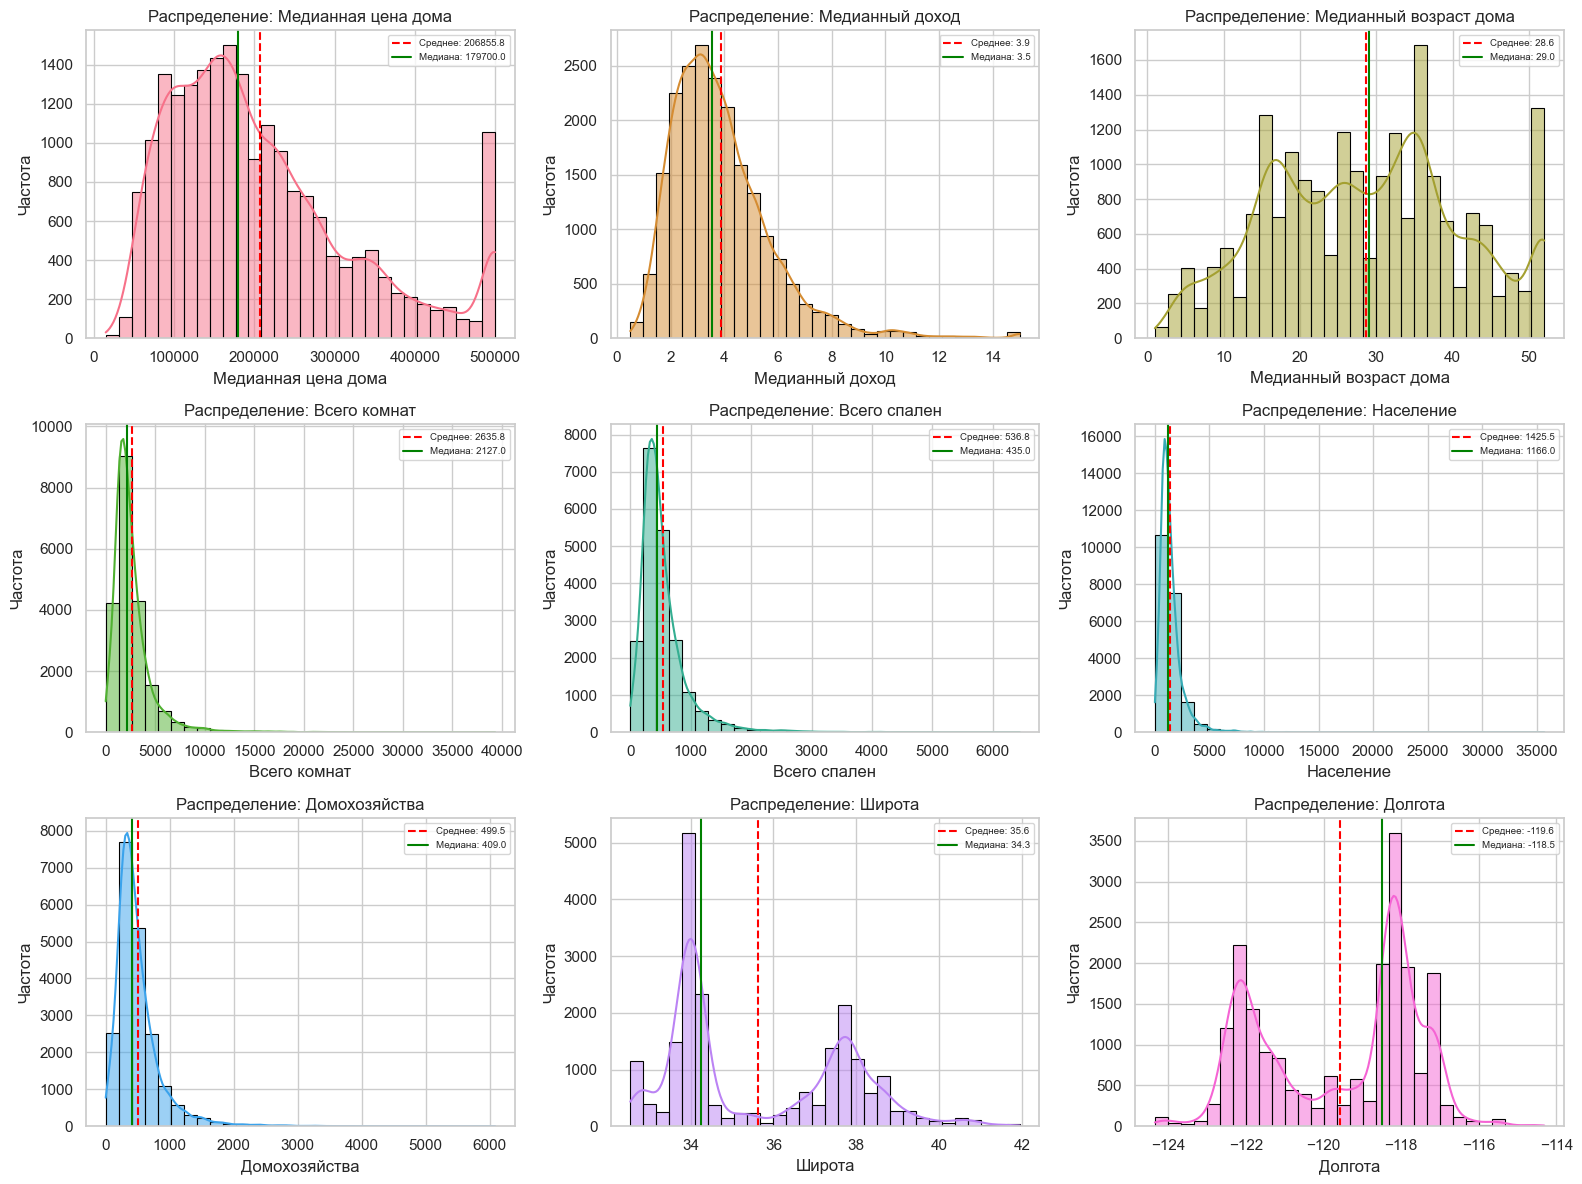

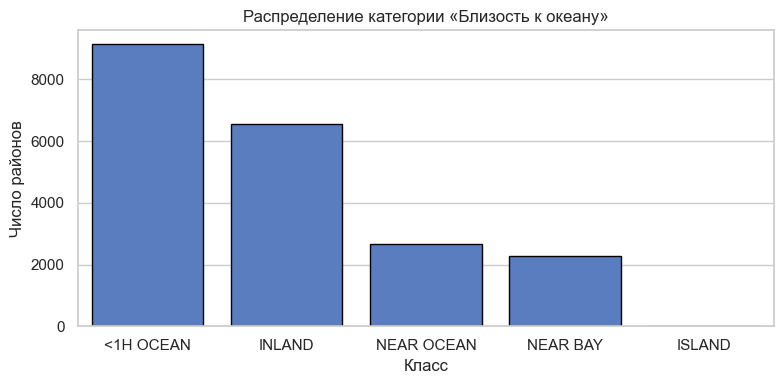

In [4]:
plot_cols = [
    "Медианная цена дома", "Медианный доход", "Медианный возраст дома",
    "Всего комнат", "Всего спален", "Население", "Домохозяйства", "Широта", "Долгота",
]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
colors = sns.color_palette("husl", len(plot_cols))
for ax, col, color in zip(axes.ravel(), plot_cols, colors):
    sns.histplot(df_model[col], kde=True, ax=ax, color=color, bins=30, edgecolor="black")
    ax.axvline(df_model[col].mean(), color="red", linestyle="--",
               label=f"Среднее: {df_model[col].mean():.1f}")
    ax.axvline(df_model[col].median(), color="green", linestyle="-",
               label=f"Медиана: {df_model[col].median():.1f}")
    ax.set_title(f"Распределение: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Частота")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
order = df["Близость к океану"].value_counts().index
sns.countplot(data=df, x="Близость к океану", order=order, ax=ax, edgecolor="black")
ax.set_title("Распределение категории «Близость к океану»")
ax.set_xlabel("Класс")
ax.set_ylabel("Число районов")
plt.tight_layout()
plt.show()


### Пояснение к графикам распределения признаков

- Цена имеет правый хвост и пик около \$500 000 из‑за цензурирования — логарифмирование цели возможно, но в базовой постановке работаем с исходной шкалой.
- `Медианный доход` тоже скошен вправо; комнаты, спальни, население и домохозяйства — тяжёлые правые хвосты (крупные районы).
- Координаты отражают географию Калифорнии (два «пятна» — побережье и внутренние районы).
- По категории доминируют `<1H OCEAN` (9136) и `INLAND` (6551); класс `ISLAND` почти отсутствует (5 наблюдений).


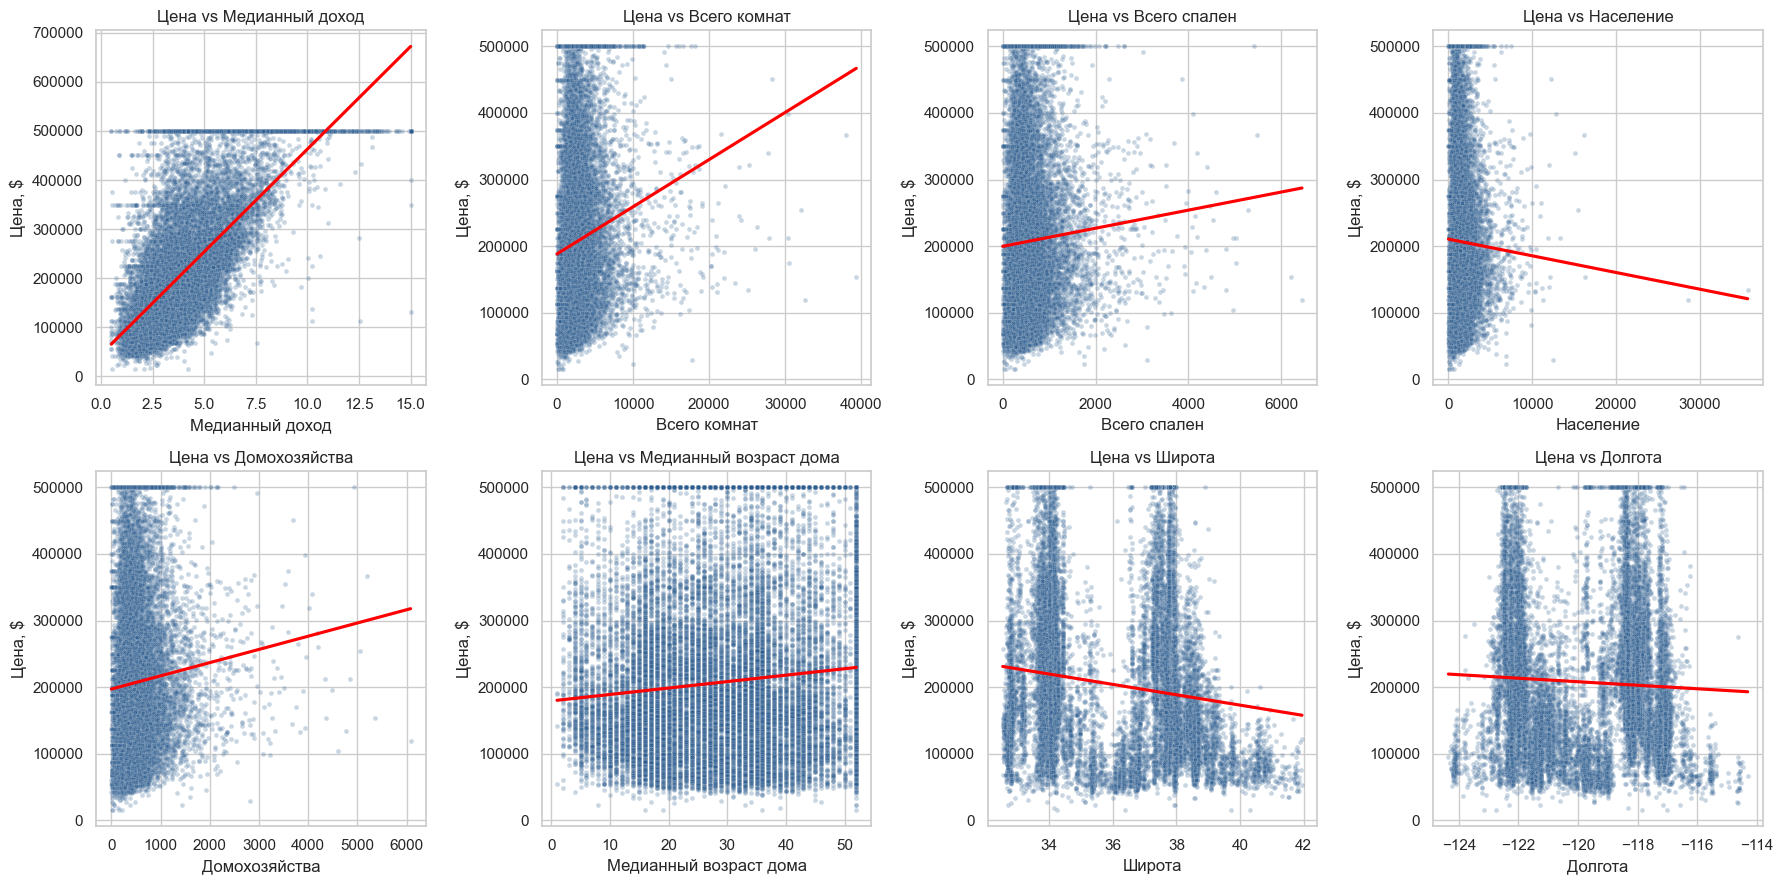

In [5]:
features_scatter = [
    "Медианный доход", "Всего комнат", "Всего спален", "Население",
    "Домохозяйства", "Медианный возраст дома", "Широта", "Долгота",
]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.ravel(), features_scatter):
    sns.scatterplot(
        data=df_model, x=col, y=TARGET, ax=ax, alpha=0.25, s=12, color="#2b5c8f"
    )
    sns.regplot(
        data=df_model, x=col, y=TARGET, scatter=False, ax=ax, color="red", ci=None
    )
    ax.set_title(f"Цена vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Цена, $")
plt.tight_layout()
plt.show()


### Пояснение к зависимости цены от признаков

Самая ясная положительная связь — **`Медианный доход` ↔ цена**. У комнат/спален/домохозяйств слабый положительный наклон на фоне сильного шума. Координаты показывают пространственную структуру (дороже ближе к побережью и заливу). Практически: главный числовой предиктор — доход; география и категория океана тоже важны.


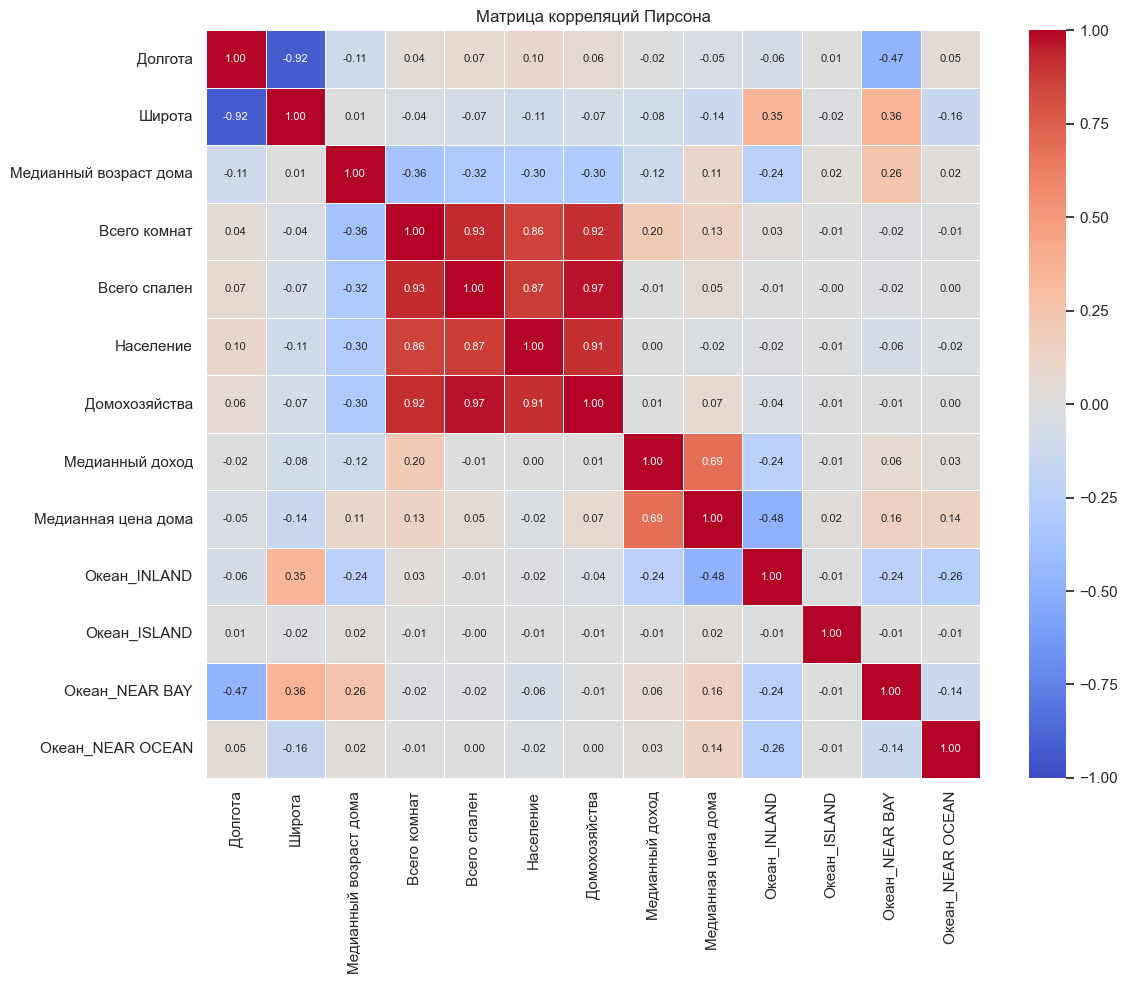

Корреляция признаков с ценой:


,Корреляция с ценой
Медианный доход,0.688
Океан_NEAR BAY,0.160
Океан_NEAR OCEAN,0.142
Всего комнат,0.134
Медианный возраст дома,0.106
Домохозяйства,0.066
Всего спален,0.049
Океан_ISLAND,0.023
Население,-0.025
Долгота,-0.046


In [ ]:
corr_matrix = df_model.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 8})
plt.title("Матрица корреляций Пирсона")
plt.tight_layout()
plt.show()

print("Корреляция признаков с ценой:")
display(
    corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
    .round(3).to_frame("Корреляция с ценой")
)


### Пояснение к матрице корреляций

- **С ценой:** `Медианный доход` даёт $r \approx 0.688$ (сильнейший предиктор). `Океан_INLAND` ≈ −0.485 (внутренние районы заметно дешевле). `NEAR BAY` / `NEAR OCEAN` слабо положительны (~0.14–0.16).
- **Между предикторами:** очень высокие связи `Всего комнат`–`Всего спален`–`Домохозяйства`–`Население` ($|r|$ часто $> 0.85$), а также `Долгота`–`Широта`. Это прямой сигнал **мультиколлинеарности**.


,Признак,VIF
0,Домохозяйства,28.315
1,Всего спален,27.040
2,Широта,19.926
3,Долгота,18.028
4,Всего комнат,12.349
5,Население,6.342
6,Океан_INLAND,2.854
7,Медианный доход,1.740
8,Океан_NEAR BAY,1.566
9,Медианный возраст дома,1.322


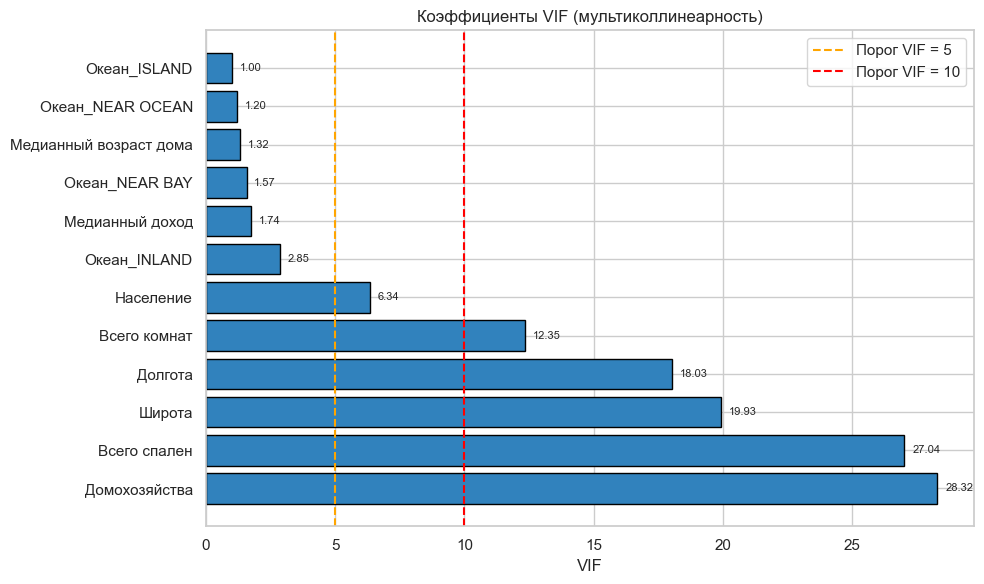

In [7]:
X_all = df_model.drop(columns=[TARGET])
scaler_vif = StandardScaler()
X_vif = pd.DataFrame(scaler_vif.fit_transform(X_all), columns=X_all.columns)

vif_df = pd.DataFrame({
    "Признак": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)
display(vif_df.round(3))

plt.figure(figsize=(10, 6))
bars = plt.barh(vif_df["Признак"], vif_df["VIF"], color="#3182bd", edgecolor="black")
plt.axvline(5.0, color="orange", linestyle="--", linewidth=1.5, label="Порог VIF = 5")
plt.axvline(10.0, color="red", linestyle="--", linewidth=1.5, label="Порог VIF = 10")
plt.title("Коэффициенты VIF (мультиколлинеарность)")
plt.xlabel("VIF")
for bar in bars:
    val = bar.get_width()
    plt.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()


### Пояснение к VIF

$$
VIF_i = \frac{1}{1 - R_i^2}
$$

Ориентиры: $VIF < 5$ — мультиколлинеарности нет; $5$–$10$ — умеренная; $> 10$ — критическая.

Здесь **критическая** мультиколлинеарность:
- `Домохозяйства` ≈ **28.3**, `Всего спален` ≈ **27.0**, `Широта` ≈ **19.9**, `Долгота` ≈ **18.0**, `Всего комнат` ≈ **12.3**.
- `Население` ≈ **6.3** (умеренная).
- Дамми океана и `Медианный доход` — в норме ($VIF < 3$).

Вывод: оценки OLS могут быть неустойчивы; регуляризация (Ridge/Lasso) и/или PCA обоснованы.


## 3. Подготовка данных

Пропуски заполнены, категория закодирована, корреляции и VIF разобраны. Разбиваем на train/test (80/20) и стандартизируем признаки.


In [8]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")
print(f"Число признаков: {X_train.shape[1]}")
print(f"Средняя цена на обучении, $: {y_train.mean():.2f}")
print("\nСредние стандартизованных признаков на обучении (ожидаются ≈ 0):")
display(X_train_scaled.mean().round(8).to_frame("Среднее"))


Обучающая выборка: 16512 объектов
Тестовая выборка: 4128 объектов
Число признаков: 12
Средняя цена на обучении, $: 207194.69

Средние стандартизованных признаков на обучении (ожидаются ≈ 0):


,Среднее
Долгота,0.0
Широта,0.0
Медианный возраст дома,-0.0
Всего комнат,0.0
Всего спален,-0.0
Население,-0.0
Домохозяйства,-0.0
Медианный доход,-0.0
Океан_INLAND,-0.0
Океан_ISLAND,-0.0


### Пояснение к предобработке и разбиению

- **Train/test:** 16 512 / 4 128 объектов (`test_size=0.2`, `random_state=42`).
- **Стандартизация:** $z=(x-\mu)/\sigma$. Параметры считаются **только на train** (`fit`), к тесту применяется `transform`. Цена не стандартизируется.
- **Кросс-валидация:** 5 блоков с перемешиванием на обучающей выборке. Тест в подборе гиперпараметров не участвует.


## 4. Ход работы. Регрессия на исходных признаках

Строим OLS, Ridge и Lasso. Параметр `alpha` для Ridge/Lasso подбираем через `GridSearchCV` по сетке значений.


Подбор гиперпараметров (GridSearchCV, 5-fold, метрика R²)
Сетка alpha: [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
Лучший alpha Ridge: 10.0 (CV R² = 0.647708)
Лучший alpha Lasso: 50.0 (CV R² = 0.647688)


,alpha,Ridge CV R²,Lasso CV R²
0,0.01,0.647676,0.647676
1,0.10,0.647676,0.647676
2,1.00,0.647680,0.647676
3,10.00,0.647708,0.647682
4,50.00,0.647639,0.647688
5,100.00,0.647274,0.647657
6,500.00,0.641916,0.645902
7,1000.00,0.635070,0.641766


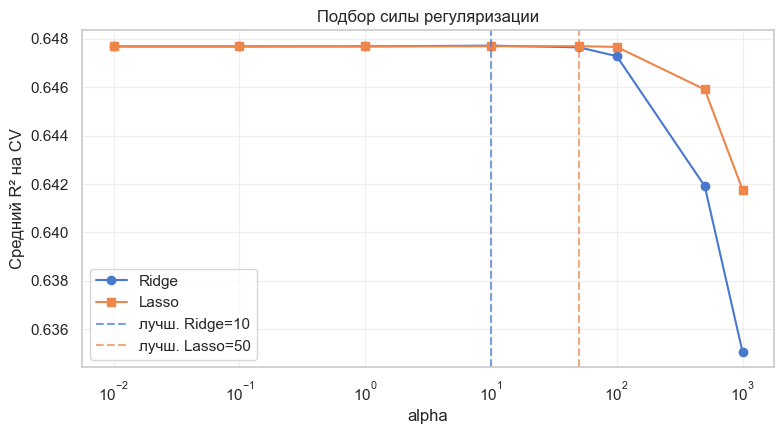

In [9]:
alpha_grid = {"alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]}

ridge_search = GridSearchCV(
    Ridge(random_state=42), alpha_grid, cv=kf, scoring="r2", n_jobs=-1
)
ridge_search.fit(X_train_scaled, y_train)
best_ridge_alpha = float(ridge_search.best_params_["alpha"])

lasso_search = GridSearchCV(
    Lasso(max_iter=50000, random_state=42), alpha_grid, cv=kf, scoring="r2", n_jobs=-1
)
lasso_search.fit(X_train_scaled, y_train)
best_lasso_alpha = float(lasso_search.best_params_["alpha"])

print("Подбор гиперпараметров (GridSearchCV, 5-fold, метрика R²)")
print(f"Сетка alpha: {alpha_grid['alpha']}")
print(f"Лучший alpha Ridge: {best_ridge_alpha} (CV R² = {ridge_search.best_score_:.6f})")
print(f"Лучший alpha Lasso: {best_lasso_alpha} (CV R² = {lasso_search.best_score_:.6f})")

ridge_cv = pd.DataFrame({
    "alpha": alpha_grid["alpha"],
    "Ridge CV R²": ridge_search.cv_results_["mean_test_score"],
})
lasso_cv = pd.DataFrame({
    "alpha": alpha_grid["alpha"],
    "Lasso CV R²": lasso_search.cv_results_["mean_test_score"],
})
display(ridge_cv.merge(lasso_cv, on="alpha").round(6))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(ridge_cv["alpha"], ridge_cv["Ridge CV R²"], "o-", label="Ridge")
ax.semilogx(lasso_cv["alpha"], lasso_cv["Lasso CV R²"], "s-", label="Lasso")
ax.axvline(best_ridge_alpha, color="C0", linestyle="--", alpha=0.7,
           label=f"лучш. Ridge={best_ridge_alpha:g}")
ax.axvline(best_lasso_alpha, color="C1", linestyle="--", alpha=0.7,
           label=f"лучш. Lasso={best_lasso_alpha:g}")
ax.set_xlabel("alpha")
ax.set_ylabel("Средний R² на CV")
ax.set_title("Подбор силы регуляризации")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Пояснение к подбору `alpha`

Для Ridge и Lasso выполнен перебор `alpha` на сетке $\{0.01, 0.1, 1, 10, 50, 100, 500, 1000\}$ с 5-фолдовой CV по $R^2$.

- Лучший **Ridge: `alpha = 10`**, CV-$R^2 \approx 0.6477$.
- Лучший **Lasso: `alpha = 50`**, CV-$R^2 \approx 0.6477$.

Умеренная регуляризация чуть стабилизирует оценки при высокой мультиколлинеарности; слишком большие `alpha` ухудшают CV-$R^2$. Дальше модели обучаем с найденными лучшими `alpha`.


In [10]:
model_lin = LinearRegression()
model_ridge = Ridge(alpha=best_ridge_alpha, random_state=42)
model_lasso = Lasso(alpha=best_lasso_alpha, max_iter=50000, random_state=42)

models_orig = {
    "Линейная (OLS)": model_lin,
    f"Ridge (alpha={best_ridge_alpha:g})": model_ridge,
    f"Lasso (alpha={best_lasso_alpha:g})": model_lasso,
}

results_orig = {}
preds_orig = {}

print("=== Модели на исходных стандартизованных признаках ===")
for name, model in models_orig.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="r2")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    preds_orig[name] = y_pred
    rmse, r2, mape = regression_metrics(y_test, y_pred)
    results_orig[name] = {
        "R2_CV_mean": float(cv_scores.mean()),
        "R2_CV_std": float(cv_scores.std()),
        "R2_Test": r2,
        "RMSE_Test": rmse,
        "MAPE_Test": mape / 100.0,
    }
    print(
        f"{name:<28} | R²(CV): {cv_scores.mean():.4f} | "
        f"R²(тест): {r2:.4f} | RMSE: {rmse:.2f} $ | MAPE: {mape:.2f}%"
    )

df_results_orig = pd.DataFrame([
    {
        "Модель": name,
        "R2 (CV)": res["R2_CV_mean"],
        "R2 (тест)": res["R2_Test"],
        "RMSE": res["RMSE_Test"],
        "MAPE, %": res["MAPE_Test"] * 100,
    }
    for name, res in results_orig.items()
])
display(df_results_orig.round(4))

coef_df = pd.DataFrame({
    "Признак": feature_names,
    "Линейная": model_lin.coef_,
    "Ridge": model_ridge.coef_,
    "Lasso": model_lasso.coef_,
})
print("Коэффициенты при стандартизованных признаках:")
display(coef_df.round(2))
print(f"Свободный член model_lin, $: {model_lin.intercept_:.2f}")


=== Модели на исходных стандартизованных признаках ===
Линейная (OLS)               | R²(CV): 0.6477 | R²(тест): 0.6254 | RMSE: 70060.52 $ | MAPE: 29.19%
Ridge (alpha=10)             | R²(CV): 0.6477 | R²(тест): 0.6257 | RMSE: 70031.31 $ | MAPE: 29.16%


Lasso (alpha=50)             | R²(CV): 0.6477 | R²(тест): 0.6258 | RMSE: 70029.67 $ | MAPE: 29.15%


,Модель,R2 (CV),R2 (тест),RMSE,"MAPE, %"
0,Линейная (OLS),0.6477,0.6254,70060.5218,29.1907
1,Ridge (alpha=10),0.6477,0.6257,70031.3053,29.1565
2,Lasso (alpha=50),0.6477,0.6258,70029.6683,29.1465


Коэффициенты при стандартизованных признаках:


,Признак,Линейная,Ridge,Lasso
0,Долгота,-53826.65,-52721.63,-52380.62
1,Широта,-54415.70,-53268.50,-52963.13
2,Медианный возраст дома,13889.87,13895.59,13856.57
3,Всего комнат,-13094.25,-12744.50,-12048.42
4,Всего спален,43068.18,42198.59,41938.98
5,Население,-43403.43,-43266.02,-43034.62
6,Домохозяйства,18382.20,18788.76,18143.61
7,Медианный доход,75167.77,75067.53,74921.73
8,Океан_INLAND,-18506.10,-18825.46,-18935.98
9,Океан_ISLAND,2118.44,2126.30,2078.86


Свободный член model_lin, $: 207194.69


### Пояснение к моделям на исходных признаках

- **Метрики (тест):** $R^2 \approx 0.625$–$0.626$, $RMSE \approx \$70 030$–\$70 060$, $MAPE \approx 29.1\%$. CV ($\approx 0.648$) близка к тесту — сильного переобучения нет.
- **Ridge/Lasso** после GridSearch почти неотличимы от OLS и чуть лучше по RMSE/MAPE за счёт стабилизации при мультиколлинеарности.
- **Коэффициенты:** доминирует `Медианный доход` (≈ +\$75 000 на 1 σ). Сильные по модулю вклады у координат, спален, населения; `Океан_INLAND` снижает цену (≈ −\$18–19 тыс. на 1 σ дамми).


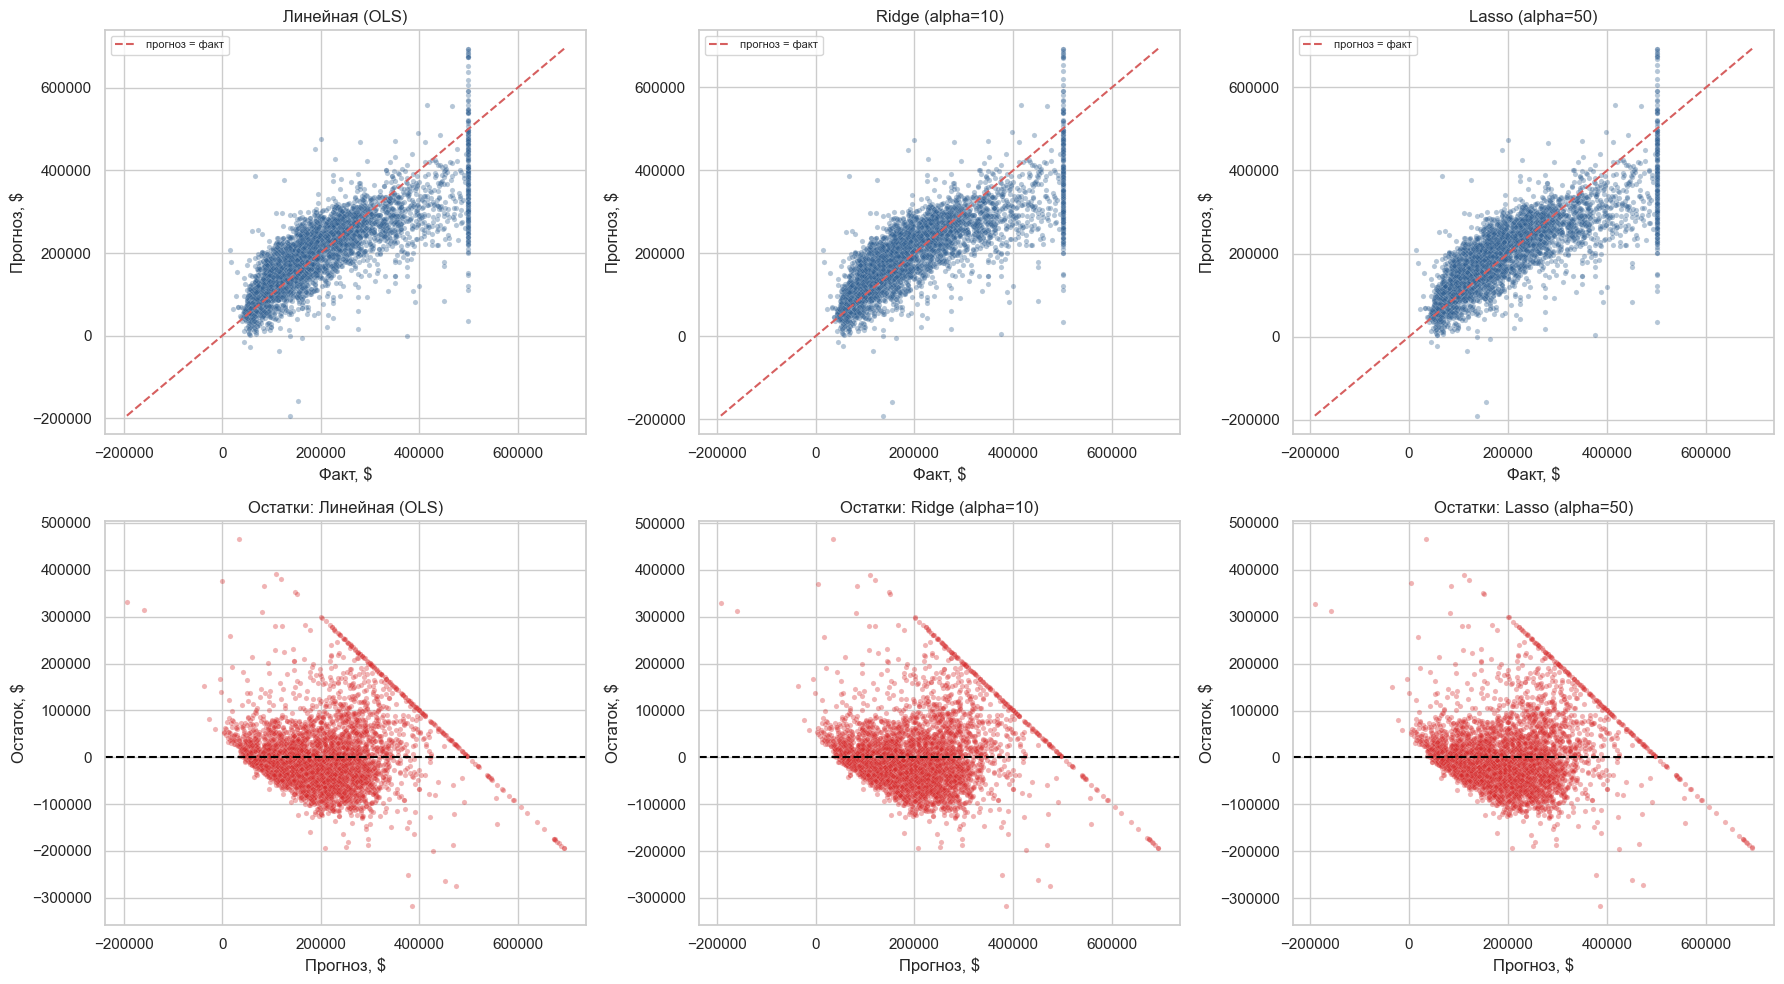

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, (name, model) in enumerate(models_orig.items()):
    y_pred = preds_orig[name]
    ax = axes[0, i]
    ax.scatter(y_test, y_pred, alpha=0.35, s=14, color="#2b5c8f",
               edgecolor="white", linewidth=0.2)
    low = min(float(y_test.min()), float(y_pred.min()))
    high = max(float(y_test.max()), float(y_pred.max()))
    ax.plot([low, high], [low, high], "r--", label="прогноз = факт")
    ax.set_title(name)
    ax.set_xlabel("Факт, $")
    ax.set_ylabel("Прогноз, $")
    ax.legend(fontsize=8)

    ax_r = axes[1, i]
    residuals = y_test.values - y_pred
    ax_r.scatter(y_pred, residuals, alpha=0.35, s=14, color="#d62728",
                 edgecolor="white", linewidth=0.2)
    ax_r.axhline(0.0, color="black", linestyle="--")
    ax_r.set_title(f"Остатки: {name}")
    ax_r.set_xlabel("Прогноз, $")
    ax_r.set_ylabel("Остаток, $")
plt.tight_layout()
plt.show()


### Пояснение к графикам прогнозов и остатков

Точки в целом следуют диагонали, но разброс заметный ($R^2 \approx 0.63$). В зоне высоких цен (около \$500 000) виден «потолок» данных — модель недооценивает часть дорогих районов.

Остатки центрированы около нуля (горизонталь $y=0$), однако амплитуда слегка растёт с прогнозом — признаки **умеренной гетероскедастичности**. OLS, Ridge и Lasso визуально почти совпадают; практически рабочими остаются все три, с небольшим преимуществом регуляризованных моделей.


## 5. PCA: каменистая осыпь и главные компоненты

Перед PCA признаки уже стандартизованы. Сравниваем два правила отбора числа компонент:
- **Правило Кайзера:** $\lambda > 1$;
- **Порог 85%** накопленной дисперсии.


,Главная компонента,Собственное значение,Доля дисперсии,Накопленная доля
0,ГК 1,3.9145,0.3262,0.3262
1,ГК 2,2.2577,0.1881,0.5143
2,ГК 3,1.5429,0.1286,0.6429
3,ГК 4,1.0770,0.0897,0.7326
4,ГК 5,1.0009,0.0834,0.8160
5,ГК 6,0.9742,0.0812,0.8972
6,ГК 7,0.5746,0.0479,0.9451
7,ГК 8,0.4165,0.0347,0.9798
8,ГК 9,0.1431,0.0119,0.9917
9,ГК 10,0.0585,0.0049,0.9966


По Кайзеру (λ > 1): 5 компонент, накопленная дисперсия = 0.8160
По порогу 85%: 6 компонент, накопленная дисперсия = 0.8972


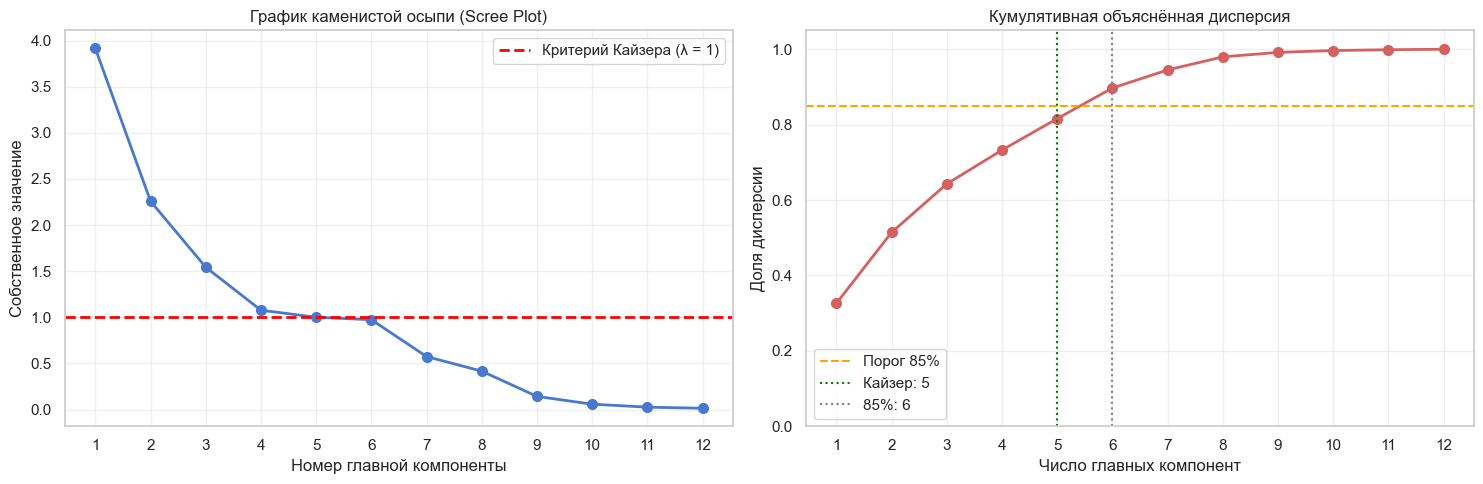

In [12]:
pca_full = PCA().fit(X_train_scaled)
eigenvalues = pca_full.explained_variance_
exp_var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var_ratio)

k_kaiser = int(np.sum(eigenvalues > 1))
k_var85 = int(np.argmax(cum_var >= 0.85) + 1)

pca_table = pd.DataFrame({
    "Главная компонента": [f"ГК {i}" for i in range(1, len(eigenvalues) + 1)],
    "Собственное значение": eigenvalues,
    "Доля дисперсии": exp_var_ratio,
    "Накопленная доля": cum_var,
})
display(pca_table.round(4))
print(f"По Кайзеру (λ > 1): {k_kaiser} компонент, накопленная дисперсия = {cum_var[k_kaiser-1]:.4f}")
print(f"По порогу 85%: {k_var85} компонент, накопленная дисперсия = {cum_var[k_var85-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(range(1, len(eigenvalues) + 1), eigenvalues, "bo-", linewidth=2, markersize=7)
axes[0].axhline(1.0, color="red", linestyle="--", linewidth=2, label="Критерий Кайзера (λ = 1)")
axes[0].set_title("График каменистой осыпи (Scree Plot)")
axes[0].set_xlabel("Номер главной компоненты")
axes[0].set_ylabel("Собственное значение")
axes[0].set_xticks(range(1, len(eigenvalues) + 1))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cum_var) + 1), cum_var, "ro-", linewidth=2, markersize=7)
axes[1].axhline(0.85, color="orange", linestyle="--", label="Порог 85%")
axes[1].axvline(k_kaiser, color="green", linestyle=":", label=f"Кайзер: {k_kaiser}")
axes[1].axvline(k_var85, color="gray", linestyle=":", label=f"85%: {k_var85}")
axes[1].set_title("Кумулятивная объяснённая дисперсия")
axes[1].set_xlabel("Число главных компонент")
axes[1].set_ylabel("Доля дисперсии")
axes[1].set_xticks(range(1, len(cum_var) + 1))
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Пояснение к графику каменистой осыпи

Первая компонента доминирует ($\lambda_1 \approx 3.92$, ~33% дисперсии), далее спад плавный. По Кайзеру значимы **5** компонент (~**81.6%** дисперсии). По порогу 85% нужны **6** из 12 (~**89.7%**). Оба варианта прогоняем через регрессию.


Факторные нагрузки:


,ГК 1,ГК 2,ГК 3,ГК 4,ГК 5,ГК 6
Долгота,0.082,-0.612,0.102,-0.087,0.059,-0.223
Широта,-0.076,0.622,0.137,0.084,-0.050,0.189
Медианный возраст дома,-0.222,0.034,-0.347,-0.509,-0.035,-0.177
Всего комнат,0.482,0.083,-0.051,0.075,0.026,-0.009
Всего спален,0.489,0.071,-0.039,-0.124,-0.023,0.011
Население,0.471,0.038,-0.033,-0.125,-0.016,-0.028
Домохозяйства,0.490,0.073,-0.066,-0.120,-0.024,0.002
Медианный доход,0.043,-0.033,-0.320,0.790,0.218,-0.141
Океан_INLAND,0.006,0.159,0.692,0.024,0.002,0.017
Океан_ISLAND,-0.005,-0.016,-0.010,-0.189,0.906,0.377



Содержательные подписи, полученные из нагрузок:
ГК 1 — «Домохозяйства / Всего спален»: +Домохозяйства (+0.49), +Всего спален (+0.49), +Всего комнат (+0.48)
ГК 2 — «Широта / Долгота»: +Широта (+0.62), -Долгота (-0.61), +Океан_NEAR BAY (+0.40)
ГК 3 — «Океан_INLAND / Океан_NEAR BAY»: +Океан_INLAND (+0.69), -Океан_NEAR BAY (-0.43), -Медианный возраст дома (-0.35)
ГК 4 — «Медианный доход / Медианный возраст дома»: +Медианный доход (+0.79), -Медианный возраст дома (-0.51), -Океан_ISLAND (-0.19)
ГК 5 — «Океан_ISLAND / Океан_NEAR OCEAN»: +Океан_ISLAND (+0.91), -Океан_NEAR OCEAN (-0.34), +Медианный доход (+0.22)
ГК 6 — «Океан_NEAR OCEAN / Океан_ISLAND»: +Океан_NEAR OCEAN (+0.81), +Океан_ISLAND (+0.38), -Океан_NEAR BAY (-0.25)


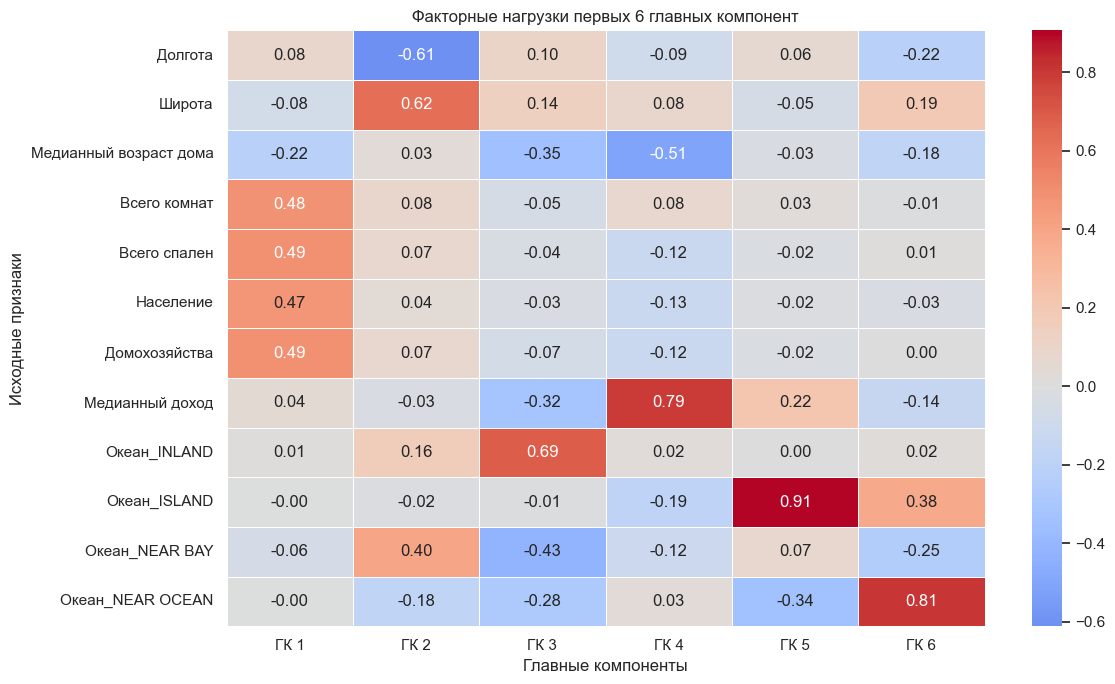

In [13]:
pca_for_labels = PCA(n_components=k_var85).fit(X_train_scaled)
loadings = pd.DataFrame(
    pca_for_labels.components_.T,
    index=feature_names,
    columns=[f"ГК {i}" for i in range(1, k_var85 + 1)],
)

pc_labels = {}
print("Факторные нагрузки:")
display(loadings.round(3))

print("\nСодержательные подписи, полученные из нагрузок:")
for i in range(1, k_var85 + 1):
    title, detail = label_component(loadings[f"ГК {i}"])
    pc_labels[i] = title
    print(f"ГК {i} — «{title}»: {detail}")

plt.figure(figsize=(12, 7))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title(f"Факторные нагрузки первых {k_var85} главных компонент")
plt.ylabel("Исходные признаки")
plt.xlabel("Главные компоненты")
plt.tight_layout()
plt.show()


### Пояснение к интерпретации главных компонент

- **ГК 1** (~32.6%) — «размер района»: высокие положительные нагрузки у `Домохозяйства`, `Всего спален`, `Всего комнат` (и населения). Ось масштаба блок-группы.
- **ГК 2** (~18.8%) — «география NW–SE»: контраст `Широта` (+) и `Долгота` (−), плюс `NEAR BAY`. Отражает расположение вдоль побережья / залива.
- **ГК 3** (~12.9%) — «внутренние районы»: доминирует `Океан_INLAND`, отрицательны `NEAR BAY` и возраст жилья.
- **ГК 4** (~9.0%) — «доход vs возраст жилья»: сильный `Медианный доход` (+) при отрицательном возрасте дома.
- **ГК 5–6** — тонкие контрасты редких классов океана (`ISLAND`, `NEAR OCEAN`).

Все ГК ортогональны — мультиколлинеарность формально снимается. При этом часть информации о цене (особенно тонкие комбинации дохода и локации) может теряться при отбрасывании хвоста компонент.


In [14]:
results_pca_all = {}
preds_pca_all = {}

for k in sorted({k_kaiser, k_var85}):
    pca_k = PCA(n_components=k).fit(X_train_scaled)
    X_train_pca = pca_k.transform(X_train_scaled)
    X_test_pca = pca_k.transform(X_test_scaled)
    names_k = [f"ГК {i}: {pc_labels.get(i, '—')}" for i in range(1, k + 1)]

    model_lin_k = LinearRegression()
    model_ridge_k = Ridge(alpha=best_ridge_alpha, random_state=42)
    model_lasso_k = Lasso(alpha=best_lasso_alpha, max_iter=50000, random_state=42)

    models_k = {
        f"Линейная (PCA, {k} ГК)": model_lin_k,
        f"Ridge (PCA, {k} ГК)": model_ridge_k,
        f"Lasso (PCA, {k} ГК)": model_lasso_k,
    }

    rule = "Кайзер" if k == k_kaiser else "порог 85%"
    print(f"=== Модели на {k} ГК ({rule}, накопл. дисперсия = {cum_var[k-1]:.4f}) ===")
    print("Признаки:", ", ".join(names_k))

    results_pca_all[k] = {}
    preds_pca_all[k] = {}
    for name, model in models_k.items():
        cv_scores = cross_val_score(model, X_train_pca, y_train, cv=kf, scoring="r2")
        model.fit(X_train_pca, y_train)
        y_pred = model.predict(X_test_pca)
        preds_pca_all[k][name] = y_pred
        rmse, r2, mape = regression_metrics(y_test, y_pred)
        results_pca_all[k][name] = {
            "R2_CV_mean": float(cv_scores.mean()),
            "R2_CV_std": float(cv_scores.std()),
            "R2_Test": r2,
            "RMSE_Test": rmse,
            "MAPE_Test": mape / 100.0,
        }
        print(
            f"{name:<28} | R²(CV): {cv_scores.mean():.4f} | "
            f"R²(тест): {r2:.4f} | RMSE: {rmse:.2f} $ | MAPE: {mape:.2f}%"
        )
    print()


=== Модели на 5 ГК (Кайзер, накопл. дисперсия = 0.8160) ===
Признаки: ГК 1: Домохозяйства / Всего спален, ГК 2: Широта / Долгота, ГК 3: Океан_INLAND / Океан_NEAR BAY, ГК 4: Медианный доход / Медианный возраст дома, ГК 5: Океан_ISLAND / Океан_NEAR OCEAN
Линейная (PCA, 5 ГК)         | R²(CV): 0.5657 | R²(тест): 0.5565 | RMSE: 76231.56 $ | MAPE: 30.29%
Ridge (PCA, 5 ГК)            | R²(CV): 0.5657 | R²(тест): 0.5565 | RMSE: 76230.66 $ | MAPE: 30.30%
Lasso (PCA, 5 ГК)            | R²(CV): 0.5657 | R²(тест): 0.5566 | RMSE: 76229.57 $ | MAPE: 30.30%

=== Модели на 6 ГК (порог 85%, накопл. дисперсия = 0.8972) ===
Признаки: ГК 1: Домохозяйства / Всего спален, ГК 2: Широта / Долгота, ГК 3: Океан_INLAND / Океан_NEAR BAY, ГК 4: Медианный доход / Медианный возраст дома, ГК 5: Океан_ISLAND / Океан_NEAR OCEAN, ГК 6: Океан_NEAR OCEAN / Океан_ISLAND


Линейная (PCA, 6 ГК)         | R²(CV): 0.5702 | R²(тест): 0.5583 | RMSE: 76076.94 $ | MAPE: 30.35%
Ridge (PCA, 6 ГК)            | R²(CV): 0.5702 | R²(тест): 0.5583 | RMSE: 76076.02 $ | MAPE: 30.35%
Lasso (PCA, 6 ГК)            | R²(CV): 0.5702 | R²(тест): 0.5584 | RMSE: 76073.50 $ | MAPE: 30.35%



### Пояснение к моделям на главных компонентах

- **6 ГК (порог 85%):** $R^2 \approx 0.558$, RMSE ≈ \$76 075, MAPE ≈ 30.4% — хуже исходных признаков.
- **5 ГК (Кайзер):** ещё чуть слабее ($R^2 \approx 0.557$, RMSE ≈ \$76 230, MAPE ≈ 30.3%).

PCA успешно убирает мультиколлинеарность, но сжатие 12 → 5/6 компонент теряет часть прогнозной информации. На этом наборе **исходные стандартизованные признаки + умеренная регуляризация** дают лучшее качество, чем PCA-регрессия.


Сводная таблица:


,Модель,Признаки,R2 (CV),R2 (тест),RMSE,"MAPE, %"
0,Lasso (alpha=50),Исходные (12),0.6477,0.6258,70029.6683,29.1465
1,Ridge (alpha=10),Исходные (12),0.6477,0.6257,70031.3053,29.1565
2,Линейная (OLS),Исходные (12),0.6477,0.6254,70060.5218,29.1907
3,"Lasso (PCA, 6 ГК)","PCA (6 ГК, 85%)",0.5702,0.5584,76073.5000,30.3520
4,"Ridge (PCA, 6 ГК)","PCA (6 ГК, 85%)",0.5702,0.5583,76076.0182,30.3526
5,"Линейная (PCA, 6 ГК)","PCA (6 ГК, 85%)",0.5702,0.5583,76076.9434,30.3495
6,"Lasso (PCA, 5 ГК)","PCA (5 ГК, Кайзер)",0.5657,0.5566,76229.5728,30.2998
7,"Ridge (PCA, 5 ГК)","PCA (5 ГК, Кайзер)",0.5657,0.5565,76230.6623,30.2980
8,"Линейная (PCA, 5 ГК)","PCA (5 ГК, Кайзер)",0.5657,0.5565,76231.5589,30.2948


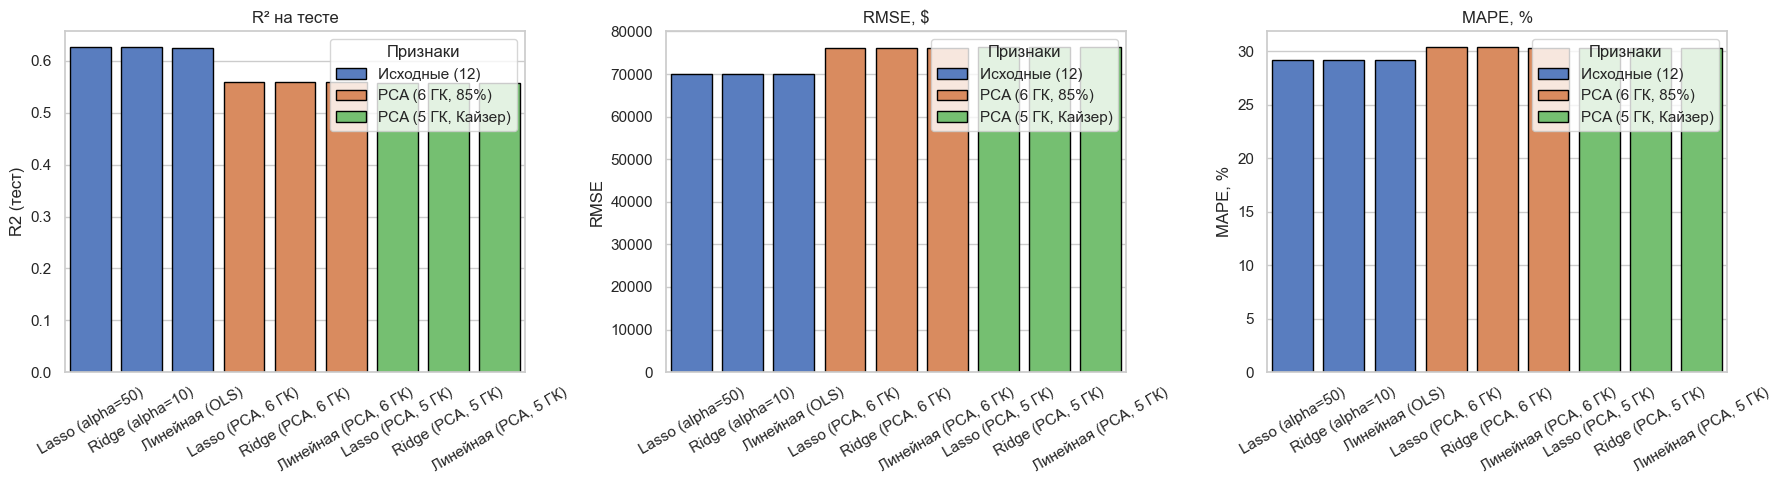

In [15]:
summary_rows = []
for name, res in results_orig.items():
    summary_rows.append({
        "Модель": name,
        "Признаки": f"Исходные ({len(feature_names)})",
        "R2 (CV)": res["R2_CV_mean"],
        "R2 (тест)": res["R2_Test"],
        "RMSE": res["RMSE_Test"],
        "MAPE, %": res["MAPE_Test"] * 100,
    })
for k, res_dict in results_pca_all.items():
    space = f"PCA ({k} ГК, {'Кайзер' if k == k_kaiser else '85%'})"
    for name, res in res_dict.items():
        summary_rows.append({
            "Модель": name,
            "Признаки": space,
            "R2 (CV)": res["R2_CV_mean"],
            "R2 (тест)": res["R2_Test"],
            "RMSE": res["RMSE_Test"],
            "MAPE, %": res["MAPE_Test"] * 100,
        })

summary = pd.DataFrame(summary_rows).sort_values("R2 (тест)", ascending=False).reset_index(drop=True)
print("Сводная таблица:")
display(summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=summary, x="Модель", y="R2 (тест)", hue="Признаки", ax=axes[0], edgecolor="black")
axes[0].set_title("R² на тесте")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary, x="Модель", y="RMSE", hue="Признаки", ax=axes[1], edgecolor="black")
axes[1].set_title("RMSE, $")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary, x="Модель", y="MAPE, %", hue="Признаки", ax=axes[2], edgecolor="black")
axes[2].set_title("MAPE, %")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


### Пояснение к итоговому сравнению

1. **Лучший блок** — исходные признаки: $R^2 \approx 0.626$, RMSE ≈ \$70 030, MAPE ≈ 29.1%. После GridSearch Lasso/Ridge слегка обходят OLS.
2. **PCA (5 и 6 ГК)** заметно хуже по всем трём метрикам: мультиколлинеарность снята, но точность прогноза упала.
3. Практический вывод: при наличии сильной мультиколлинеарности **Ridge/Lasso на исходных признаках** предпочтительнее агрессивного сжатия через PCA, если цель — качество прогноза.


In [16]:
weights_payload = {
    "датасет": "camnugent/california-housing-prices",
    "обучающая_выборка": int(X_train.shape[0]),
    "тестовая_выборка": int(X_test.shape[0]),
    "подбор_гиперпараметров": {
        "сетка_alpha": alpha_grid["alpha"],
        "лучший_alpha_Ridge": best_ridge_alpha,
        "лучший_alpha_Lasso": best_lasso_alpha,
        "CV_R2_Ridge": float(ridge_search.best_score_),
        "CV_R2_Lasso": float(lasso_search.best_score_),
    },
    "модели_на_исходных_признаках": {
        name: {
            **res,
            "intercept": float(models_orig[name].intercept_),
            "coefficients": {
                col: float(coef) for col, coef in zip(feature_names, models_orig[name].coef_)
            },
        }
        for name, res in results_orig.items()
    },
    "факторный_анализ_pca": {
        "компонент_по_Кайзеру": int(k_kaiser),
        "компонент_по_порогу_85": int(k_var85),
        "подписи_компонент_из_нагрузок": {f"ГК_{i}": pc_labels[i] for i in pc_labels},
        "собственные_значения": [float(e) for e in eigenvalues],
        "факторные_нагрузки": {
            col: {f"ГК_{i}": float(loadings.loc[col, f"ГК {i}"]) for i in range(1, k_var85 + 1)}
            for col in feature_names
        },
    },
    "модели_на_главных_компонентах": {
        f"{k}_ГК": results_pca_all[k] for k in results_pca_all
    },
}

with open("laba1_model_weights.json", "w", encoding="utf-8") as f:
    json.dump(weights_payload, f, ensure_ascii=False, indent=2)

weights_csv_df = pd.DataFrame({
    "Признак": feature_names,
    "Линейная_регрессия_OLS": model_lin.coef_,
    "Гребневая_регрессия_Ridge": model_ridge.coef_,
    "Лассо_регрессия_Lasso": model_lasso.coef_,
})
weights_csv_df.to_csv("laba1_weights.csv", index=False)

print("Веса моделей:")
display(weights_csv_df.round(3))
print(f"Intercept линейной регрессии: {model_lin.intercept_:.2f} $")
print("Сохранены: laba1_model_weights.json, laba1_weights.csv")


Веса моделей:


,Признак,Линейная_регрессия_OLS,Гребневая_регрессия_Ridge,Лассо_регрессия_Lasso
0,Долгота,-53826.648,-52721.631,-52380.617
1,Широта,-54415.696,-53268.497,-52963.132
2,Медианный возраст дома,13889.866,13895.589,13856.568
3,Всего комнат,-13094.251,-12744.503,-12048.421
4,Всего спален,43068.182,42198.585,41938.981
5,Население,-43403.432,-43266.019,-43034.621
6,Домохозяйства,18382.196,18788.756,18143.613
7,Медианный доход,75167.775,75067.528,74921.730
8,Океан_INLAND,-18506.095,-18825.456,-18935.977
9,Океан_ISLAND,2118.438,2126.300,2078.856


Intercept линейной регрессии: 207194.69 $
Сохранены: laba1_model_weights.json, laba1_weights.csv


### Пояснение к коэффициентам и файлам весов

Признаки стандартизованы, поэтому коэффициент показывает, на сколько долларов меняется прогноз цены при росте признака на одно стандартное отклонение.

Ранжирование влияния (по модулю коэффициента OLS):
- **Медианный доход** ≈ +75 168 — главный предиктор.
- **Широта / Долгота** ≈ −54 тыс. — географический эффект (дороже на побережье/заливе при прочих равных в комбинации с дамми океана).
- **Всего спален** ≈ +43 068; **Население** ≈ −43 403 — при контроле на размер района.
- **Океан_INLAND** ≈ −18 506 — внутренние районы существенно дешевле.
- Возраст жилья и домохозяйства дают умеренный вклад.

Сравнение OLS / Ridge / Lasso: при `alpha_Ridge=10` и `alpha_Lasso=50` коэффициенты близки; Lasso чуть сильнее сжимает слабые веса, порядок признаков сохраняется.

Сохранённые файлы:
- `laba1_weights.csv` — таблица коэффициентов трёх моделей;
- `laba1_model_weights.json` — полный снимок эксперимента (alpha, метрики, нагрузки PCA).


## 6. Заключение

1. На датасете California Housing Prices построены OLS, Ridge и Lasso с метриками RMSE, R², MAPE.
2. В разделе **«Описание датасета»** — распределения, корреляции и VIF. Обнаружена **критическая мультиколлинеарность** (VIF до ≈ 28 у `Домохозяйства` / `Всего спален`).
3. Подготовка: заполнение 207 пропусков медианой, one-hot для `ocean_proximity`, train/test 80/20, `StandardScaler` только на train. Для Ridge/Lasso выполнен **GridSearchCV по `alpha`** (лучшие: 10 и 50).
4. Лучшие модели на исходных признаках: $R^2 \approx 0.626$, RMSE ≈ \$70 тыс., MAPE ≈ 29%. Регуляризация слегка улучшает устойчивость.
5. PCA: по Кайзеру — 5 ГК, по 85% — 6 ГК. Модели на ГК хуже исходных ($R^2 \approx 0.56$). PCA снимает мультиколлинеарность, но не повышает точность прогноза.
6. **Итог:** рабочая модель — **Ridge/Lasso (или OLS)** на стандартизованных исходных признаках; PCA здесь полезен как факторный анализ, но не как способ улучшить прогноз.

## 7. Список источников

1. Nugent C. California Housing Prices. — Kaggle. — https://www.kaggle.com/datasets/camnugent/california-housing-prices
2. Pace R. K., Barry R. Sparse Spatial Autoregressions // Statistics and Probability Letters. — 1997.
3. Pedregosa F. et al. Scikit-learn: Machine Learning in Python // JMLR. — 2011. — Vol. 12. — P. 2825–2830.
4. James G. et al. An Introduction to Statistical Learning with Applications in Python. — Springer, 2023.
5. Флах П. Машинное обучение. — М.: ДМК Пресс, 2015.
6. Scikit-learn: Linear Models, PCA, GridSearchCV. — https://scikit-learn.org/stable/
7. Statsmodels: variance_inflation_factor. — https://www.statsmodels.org/

## 8. Приложение

Программный код вынесен в отдельные модули (как в образце лабораторной):

- `laba1_analysis.py` — загрузка датасета, предобработка, описательная статистика, распределения, scatter-графики, корреляции, VIF;
- `laba1_models.py` — train/test, стандартизация, GridSearchCV, OLS/Ridge/Lasso, графики прогнозов и остатков, PCA, сравнение метрик, сохранение весов.

Запуск из папки проекта:

```bash
python laba1_analysis.py
python laba1_models.py
```

Графики сохраняются в папку `figures/`:

1. `01_distributions.png` — распределения признаков
2. `02_ocean_proximity_counts.png` — категории близости к океану
3. `03_scatter_vs_price.png` — цена vs признаки
4. `04_correlation_matrix.png` — матрица корреляций
5. `05_vif.png` — коэффициенты VIF
6. `06_alpha_gridsearch.png` — подбор alpha
7. `07_predictions_residuals.png` — прогнозы и остатки
8. `08_pca_scree.png` — каменистая осыпь
9. `09_pca_loadings.png` — факторные нагрузки
10. `10_metrics_comparison.png` — сравнение RMSE / R² / MAPE

Дополнительные таблицы: `laba1_weights.csv`, `laba1_model_weights.json`, `laba1_metrics_summary.csv`, `laba1_vif.csv`, `laba1_corr_with_target.csv`, `laba1_descriptive_stats.csv`, `laba1_pca_variance.csv`, `laba1_pca_loadings.csv`.

